In [1]:
import google.generativeai as genai

# 1. Setup API Key
genai.configure(api_key="###")
model = genai.GenerativeModel('gemini-3-flash-preview')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os;
file_path = os.path.join('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud', 'creditcard.csv')

# Create the DataFrame
data = pd.read_csv(file_path)

In [3]:
metadata = {
  "features": {
    "Time": "Number of seconds elapsed between this transaction and the first transaction in the dataset",
    "V1": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V2": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V3": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V4": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V5": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V6": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V7": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V8": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V9": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V10": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V11": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V12": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V13": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V14": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V15": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V16": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V17": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V18": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V19": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V20": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V21": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V22": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V23": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V24": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V25": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V26": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V27": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V28": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "Amount": "Transaction amount",
    "Class": "1 for fraudulent transactions, 0 otherwise"
  }
}

In [6]:
sample_data = pd.concat([data[data['Class']==0].head(100), data[data['Class']==1].head(100)]).to_json(orient='records')

In [8]:
import json

# 3. Construct the Prompt
prompt = f"""
I am conducting research on LLM-assisted feature engineering for financial fraud detection.
Dataset Metadata: {json.dumps(metadata)}
Sample Data (JSON): {sample_data}

Task:
1. Analyze the features and data patterns provided.
2. Suggest 10 novel features that could improve model performance (Precision/Recall).
3. Provide the Python code using 'pandas' to create these features.
   Assume the dataframe is named 'df'.
4. Explain the logic behind why each feature helps in detecting fraud.
"""

# 4. Generate Content
response = model.generate_content(prompt)
print(response.text)

Based on the metadata and sample data provided, we are dealing with the classic "Credit Card Fraud Detection" dataset. The challenge here is the extreme class imbalance and the fact that most features (`V1`-`V28`) are the result of PCA, meaning their physical meaning is obscured.

However, fraud detection typically relies on **velocity** (how fast transactions occur), **value** (amount patterns), and **outlier detection** (deviation from the norm).

### 1. Analysis of Patterns
*   **Amount Patterns:** In the sample, fraudulent transactions frequently show a repetitive amount of **$1.00** (likely card testing) or **$0.00** (authorization checks).
*   **Temporal Bursts:** Fraudulent transactions often occur in rapid succession (e.g., several transactions at the same `Time` or within a few seconds).
*   **PCA Extremes:** Fraudulent cases (Class 1) tend to have much higher absolute values in specific PCA components (like `V10`, `V12`, `V14`, and `V17`) compared to legitimate transactions.


In [13]:
import numpy as np

def engineer_features(df):
    # Ensure dataframe is sorted by Time for temporal features
    df = df.sort_values('Time')

    # 1. Hour of Day (Assuming Time is in seconds starting from 0)
    # 86400 seconds in a day
    df['HourOfDay'] = (df['Time'] % 86400) // 3600

    # 2. Amount Log (Handles skewed distribution of transaction amounts)
    df['Amount_Log'] = np.log1p(df['Amount'])

    # 3. V_Magnitude (Euclidean distance in PCA space)
    v_cols = [f'V{i}' for i in range(1, 29)]
    df['V_Magnitude'] = np.sqrt((df[v_cols]**2).sum(axis=1))

    # 4. V_Sum (Captures general directional shift across all components)
    df['V_Sum'] = df[v_cols].sum(axis=1)

    # 5. V_Std (Internal variance of the PCA components)
    df['V_Std'] = df[v_cols].std(axis=1)

    # 6. Is_Round_Amount (Fraudsters often use round numbers or test small round amounts)
    df['Is_Round_Amount'] = (df['Amount'] % 1 == 0).astype(int)

    # 7. Is_Zero_Amount (Common in card verification/testing fraud)
    df['Is_Zero_Amount'] = (df['Amount'] == 0).astype(int)

    # 8. V1_V2_Interaction (Interaction between the two most significant components)
    df['V1_V2_Interaction'] = df['V1'] * df['V2']

    # 9. Amount_to_V_Mag_Ratio (Relationship between transaction scale and PCA position)
    df['Amount_to_V_Mag_Ratio'] = df['Amount'] / (df['V_Magnitude'] + 1e-5)

    # 10. Time_Delta (Seconds since the last transaction in the stream)
    df['Time_Delta'] = df['Time'].diff().fillna(0)

    return df

# Apply to your dataframe
df = engineer_features(data)

In [14]:
# The correct way to remove a column
df = df.drop(columns=['Amount'])

In [12]:
# List of the 10 engineered features
new_features = [
    'HourOfDay', 'Amount_Log', 'V_Magnitude', 'V_Sum', 'V_Std', 
    'Is_Round_Amount', 'Is_Zero_Amount', 'V1_V2_Interaction', 
    'Amount_to_V_Mag_Ratio', 'Time_Delta'
]

# Print the first 5 rows of these specific columns
print(df[new_features].head(10))

   HourOfDay  Amount_Log  V_Magnitude     V_Sum     V_Std  Is_Round_Amount  \
0        0.0    5.014760     3.911559  3.081757  0.744389                0   
1        0.0    1.305626     2.674524  4.439726  0.488729                0   
2        0.0    5.939276     6.080512  1.091311  1.169522                0   
3        0.0    4.824306     4.284356 -2.409596  0.819854                0   
4        0.0    4.262539     3.565131  5.378728  0.657631                0   
5        0.0    1.541159     2.553739  2.924822  0.479817                0   
6        0.0    1.790091     2.816984 -0.737258  0.541465                0   
8        0.0    4.545420     5.091262  5.102096  0.962082                0   
7        0.0    3.732896     6.179383 -1.209385  1.188409                0   
9        0.0    1.543298     2.985308  4.339088  0.552424                0   

   Is_Zero_Amount  V1_V2_Interaction  Amount_to_V_Mag_Ratio  Time_Delta  
0               0           0.098968              38.250637        

In [16]:
from sklearn.metrics import (
    precision_recall_curve,
    auc,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
)

def evaluate_model(y_true, y_pred_proba, y_pred_class, model_name, method):
    """Calculates and returns key metrics, including AUPRC."""

    # Calculate Precision-Recall AUC (AUPRC) - Recommended for imbalance
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall, precision)

    # Calculate other key metrics
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    recall = recall_score(y_true, y_pred_class)
    precision = precision_score(y_true, y_pred_class)
    f1 = f1_score(y_true, y_pred_class)

    # Calculate Confusion Matrix for review
    cm = confusion_matrix(y_true, y_pred_class)
    print("confusion_matrix:\n",cm)

    tn, fp, fn, tp = cm.ravel()

    results = {
        'Model': model_name,
        'Method': method,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc,
        'Recall (Fraud)': recall,
        'Precision (Fraud)': precision,
        'F1-Score': f1,
        'True Positives (TP)': tp,
        'False Negatives (FN)': fn  # Missed Fraud - critical risk
    }
    return results

final_results = []

In [17]:
from sklearn.model_selection import train_test_split
X = df.drop('Class', axis=1).copy()
y = df['Class'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

cols = ['Time', 'Amount_Log', 'HourOfDay', 'Amount_Log', 'V_Magnitude', 'V_Sum', 'V_Std', 
    'Is_Round_Amount', 'Is_Zero_Amount', 'V1_V2_Interaction', 
    'Amount_to_V_Mag_Ratio', 'Time_Delta']

preprocessor = ColumnTransformer(
    transformers=[
        ('scale', StandardScaler(), cols)
    ],
    remainder='passthrough'
)

In [19]:
## Handle Imbalance (SMOTE Example for Training Data)

from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(sampling_strategy='minority', random_state=42)

LR - CW

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE

lr_cw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', RFE(estimator=LogisticRegression(solver='liblinear'))),
    ('classifier', LogisticRegression(
        random_state=42,
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        max_iter=1000,
        C=0.01,
    ))
])


lr_cw.fit(X_train, y_train)
y_pred_proba_cw = lr_cw.predict_proba(X_test)[:, 1]
y_pred_class_cw = lr_cw.predict(X_test)

metrics_cw = evaluate_model(y_test, y_pred_proba_cw, y_pred_class_cw, "LR","CW")
final_results.append(metrics_cw)
print(pd.Series(metrics_cw))

confusion_matrix:
 [[83215  2080]
 [   20   128]]
Model                         LR
Method                        CW
PR-AUC                  0.677168
ROC-AUC                 0.962458
Recall (Fraud)          0.864865
Precision (Fraud)       0.057971
F1-Score                0.108659
True Positives (TP)          128
False Negatives (FN)          20
dtype: object


In [21]:
# 1. Get the original feature names from the preprocessor
# These are the names of the 30 columns before RFE cut them
original_names = lr_cw.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the "Support Mask" from the RFE selector
# This is a list of True/False values (True = kept, False = dropped)
mask = lr_cw.named_steps['selector'].get_support()

# 3. Apply the mask to the original names to get the 10 selected features
selected_names = original_names[mask]

# 4. Grab the coefficients from the final classifier
# These 10 coefficients match the 10 selected_names
coefficients = lr_cw.named_steps['classifier'].coef_[0]

# 5. Combine into a readable DataFrame or Series
feature_importance = pd.DataFrame({
    'Feature': selected_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                         Feature  Coefficient
7                  remainder__V4     1.188810
15                remainder__V22     0.579067
14                remainder__V21     0.381627
19                remainder__V28     0.019223
2                   scale__V_Sum     0.000000
17                remainder__V25    -0.155381
1             scale__V_Magnitude    -0.188908
4   scale__Amount_to_V_Mag_Ratio    -0.248578
9                  remainder__V9    -0.257654
6                  remainder__V3    -0.298438
13                remainder__V20    -0.354478
18                remainder__V27    -0.356000
11                remainder__V13    -0.371773
8                  remainder__V8    -0.374079
16                remainder__V23    -0.462003
5                  remainder__V2    -0.515792
0                    scale__Time    -0.589925
12                remainder__V14    -0.786975
10                remainder__V10    -0.867002
3       scale__V1_V2_Interaction    -1.137650


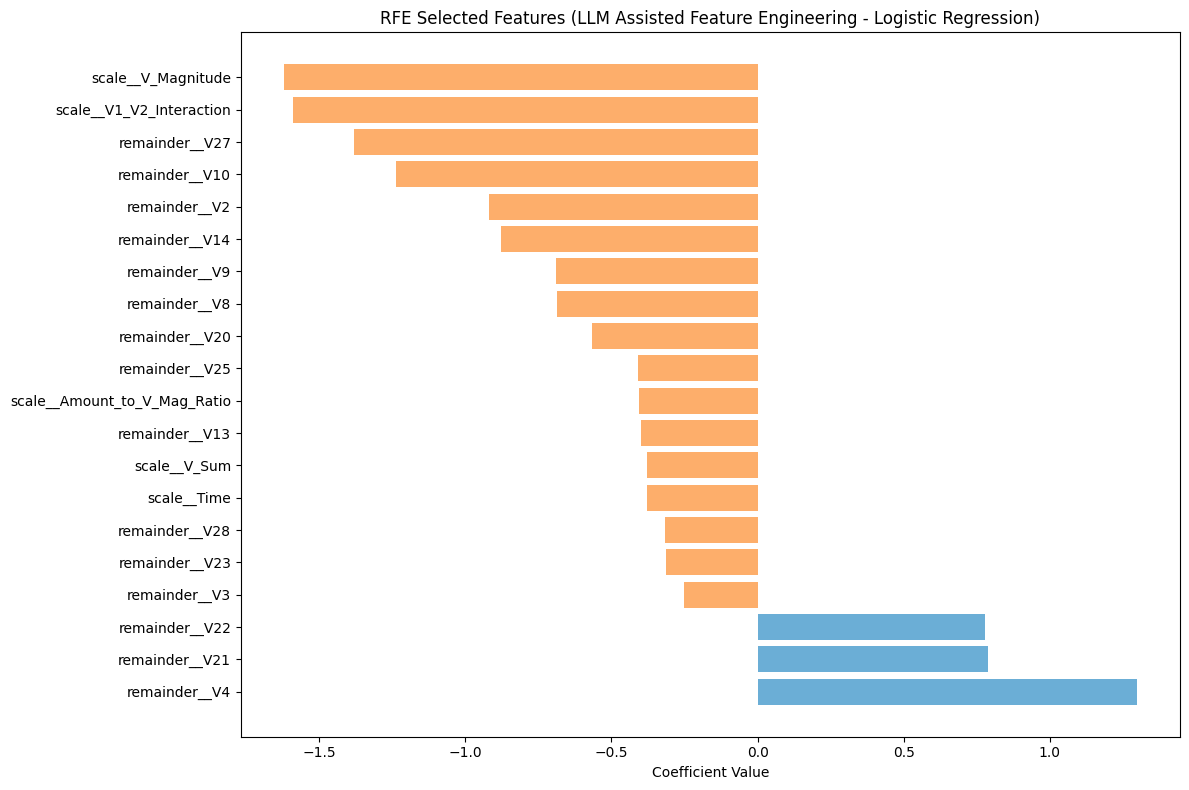

In [22]:
feature_names = lr_cw.named_steps['preprocessor'].get_feature_names_out()
selector = lr_cw.named_steps['selector']
selected_mask = selector.support_
selected_features = feature_names[selected_mask]

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Get coefficients
coefs = selector.estimator_.coef_[0]


# Use absolute value for ranking
#importance = np.abs(coefs)
importance = coefs

# Sort
indices = np.argsort(importance)

sorted_importance = importance[indices]
sorted_features = np.array(selected_features)[indices]

# Soft professional color
#colors = cm.GnBu(np.linspace(0.3, 0.8, len(indices)))
colors = ['#6baed6' if c > 0 else '#fdae6b' for c in sorted_importance]

plt.figure(figsize=(12, 8))
plt.barh(range(len(indices)), sorted_importance, color=colors)

plt.yticks(range(len(indices)), sorted_features)
plt.xlabel("Coefficient Value")
plt.title("RFE Selected Features (LLM Assisted Feature Engineering - Logistic Regression)")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

LR - SMOTE

In [23]:
from imblearn.pipeline import Pipeline as ImbPipeline

lr_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('selector', RFE(estimator=LogisticRegression(solver='liblinear'), n_features_to_select=10)),
    ('classifier', LogisticRegression(
        random_state=42,
        C=0.01,
        max_iter=1000,
        solver='liblinear',
        penalty='l1',
        class_weight=None,
    ))
])

# Train on the SMOTE-resampled training data
lr_smote.fit(X_train, y_train)
y_pred_proba_smote = lr_smote.predict_proba(X_test)[:, 1]
y_pred_class_smote = lr_smote.predict(X_test)

metrics_smote = evaluate_model(y_test, y_pred_proba_smote, y_pred_class_smote, "LR", "SMOTE")
final_results.append(metrics_smote)
print(pd.Series(metrics_smote))

confusion_matrix:
 [[83289  2006]
 [   18   130]]
Model                         LR
Method                     SMOTE
PR-AUC                  0.704671
ROC-AUC                 0.968808
Recall (Fraud)          0.878378
Precision (Fraud)       0.060861
F1-Score                0.113835
True Positives (TP)          130
False Negatives (FN)          18
dtype: object


In [24]:
# 1. Get the original feature names from the preprocessor
# These are the names of the 30 columns before RFE cut them
original_names = lr_smote.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the "Support Mask" from the RFE selector
# This is a list of True/False values (True = kept, False = dropped)
mask = lr_smote.named_steps['selector'].get_support()

# 3. Apply the mask to the original names to get the 10 selected features
selected_names = original_names[mask]

# 4. Grab the coefficients from the final classifier
# These 10 coefficients match the 10 selected_names
coefficients = lr_smote.named_steps['classifier'].coef_[0]

# 5. Combine into a readable DataFrame or Series
feature_importance = pd.DataFrame({
    'Feature': selected_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                    Feature  Coefficient
4             remainder__V4     1.189245
5             remainder__V5     0.380541
0        scale__V_Magnitude    -0.036266
3             remainder__V2    -0.471195
6             remainder__V8    -0.587536
8            remainder__V12    -0.668986
1              scale__V_Std    -0.734938
7            remainder__V10    -0.899461
9            remainder__V14    -1.030613
2  scale__V1_V2_Interaction    -1.321739


RF - CW

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

rf_cw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(
        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
        threshold="mean"
    )),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        n_jobs = -1,
        class_weight='balanced',
        criterion='entropy',
        max_depth=30,
        max_features='sqrt',
        min_samples_split=2
    ))
])

rf_cw.fit(X_train, y_train)
y_pred_proba_cw = rf_cw.predict_proba(X_test)[:, 1]
y_pred_class_cw = rf_cw.predict(X_test)

metrics_cw = evaluate_model(y_test, y_pred_proba_cw, y_pred_class_cw, "RF","CW")
final_results.append(metrics_cw)
print(pd.Series(metrics_cw))

confusion_matrix:
 [[85291     4]
 [   41   107]]
Model                         RF
Method                        CW
PR-AUC                  0.815362
ROC-AUC                 0.930541
Recall (Fraud)          0.722973
Precision (Fraud)       0.963964
F1-Score                0.826255
True Positives (TP)          107
False Negatives (FN)          41
dtype: object


In [26]:
# 1. Get original names from preprocessor
feature_names = rf_cw.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the mask from the selection step
selector = rf_cw.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Filter names and get importance scores from the FINAL classifier
selected_names = feature_names[support_mask]
importances = rf_cw.named_steps['classifier'].feature_importances_

# 4. Create the Series
rf_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Selected {len(selected_names)} out of {len(feature_names)} features.")
print(rf_importance_series.head(10))

Selected 10 out of 40 features.
remainder__V14        0.287282
remainder__V10        0.135798
scale__V_Std          0.133457
scale__V_Magnitude    0.131126
remainder__V4         0.078256
scale__V_Sum          0.069104
remainder__V12        0.064210
remainder__V17        0.055043
remainder__V11        0.026603
remainder__V7         0.019120
dtype: float64


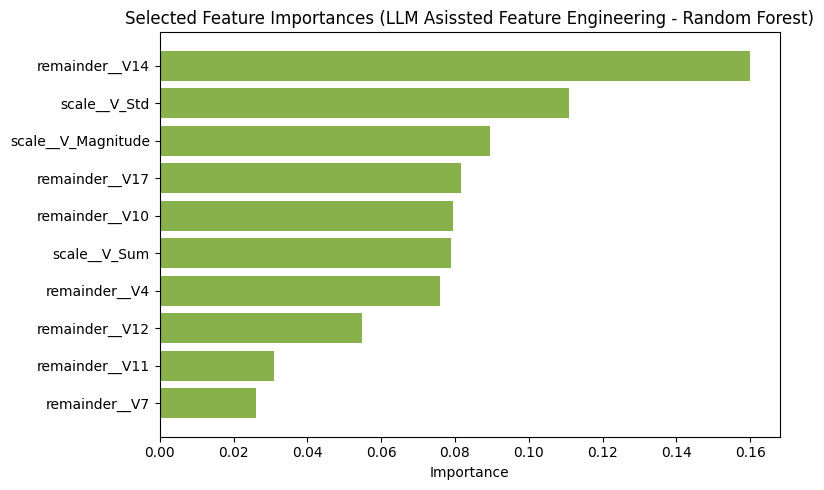

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Get feature importances from the feature selection model
importances = selector.estimator_.feature_importances_

# Keep only selected ones
selected_importances = importances[support_mask]

# Sort them
indices = np.argsort(selected_importances)

# Use a pastel colormap
#colors = cm.Pastel1(np.linspace(0, 1, len(indices)))
colors = '#88B04B'


plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), selected_importances[indices],color=colors)
plt.yticks(range(len(indices)), selected_names[indices])
plt.title("Selected Feature Importances (LLM Asissted Feature Engineering - Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

RF - SMOTE

In [28]:
rf_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectFromModel(
        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
        threshold="mean"
    )),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        n_jobs = -1,
        class_weight=None,
        criterion='entropy',
        max_depth=30,
        max_features='log2',
        min_samples_split=10
    ))
])

# Train on the SMOTE-resampled training data
rf_smote.fit(X_train, y_train)
y_pred_proba_smote = rf_smote.predict_proba(X_test)[:, 1]
y_pred_class_smote = rf_smote.predict(X_test)

metrics_smote = evaluate_model(y_test, y_pred_proba_smote, y_pred_class_smote, "RF","SMOTE")
final_results.append(metrics_smote)
print(pd.Series(metrics_smote))

confusion_matrix:
 [[85210    85]
 [   26   122]]
Model                         RF
Method                     SMOTE
PR-AUC                  0.804235
ROC-AUC                 0.952069
Recall (Fraud)          0.824324
Precision (Fraud)       0.589372
F1-Score                0.687324
True Positives (TP)          122
False Negatives (FN)          26
dtype: object


In [29]:
# 1. Get original names from preprocessor
feature_names = rf_smote.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the mask from the selection step
selector = rf_smote.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Filter names and get importance scores from the FINAL classifier
selected_names = feature_names[support_mask]
importances = rf_smote.named_steps['classifier'].feature_importances_

# 4. Create the Series
rf_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Selected {len(selected_names)} out of {len(feature_names)} features.")
print(rf_importance_series.head(10))

Selected 9 out of 40 features.
remainder__V14        0.308816
remainder__V10        0.165427
scale__V_Std          0.147180
remainder__V4         0.089909
scale__V_Sum          0.077628
scale__V_Magnitude    0.074616
remainder__V12        0.058612
remainder__V17        0.044706
remainder__V11        0.033107
dtype: float64


XGB - CW

In [30]:
!pip install xgboost

In [31]:
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb
from collections import Counter

counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]
xgb_cw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(
        xgb.XGBClassifier(n_estimators=100, random_state=42),
        threshold="median" # Keeps the top 50% of features
    )),
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        max_depth=6,
        gamma=1,
        learning_rate=0.05,
        n_estimators=200,
        n_jobs=-1
    ))
])

xgb_cw.fit(X_train, y_train)
y_pred_proba_cw = xgb_cw.predict_proba(X_test)[:, 1]
y_pred_class_cw = xgb_cw.predict(X_test)

metrics_cw = evaluate_model(y_test, y_pred_proba_cw, y_pred_class_cw, "XGB","CW")
final_results.append(metrics_cw)
print(pd.Series(metrics_cw))

confusion_matrix:
 [[85236    59]
 [   28   120]]
Model                        XGB
Method                        CW
PR-AUC                  0.808375
ROC-AUC                 0.966725
Recall (Fraud)          0.810811
Precision (Fraud)       0.670391
F1-Score                0.733945
True Positives (TP)          120
False Negatives (FN)          28
dtype: object


In [32]:
# 1. Get original feature names from the preprocessor
feature_names = xgb_cw.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the selection mask
selector = xgb_cw.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Apply mask to names
selected_names = feature_names[support_mask]

# 4. Map back to the FINAL classifier's feature importances
importances = xgb_cw.named_steps['classifier'].feature_importances_
xgb_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Features selected: {len(selected_names)} out of {len(feature_names)}")
print(xgb_importance_series.head(10))

Features selected: 20 out of 40
remainder__V14        0.600285
remainder__V4         0.058737
remainder__V10        0.045378
scale__V_Magnitude    0.034603
remainder__V12        0.033040
scale__V_Std          0.023656
remainder__V21        0.020938
scale__Amount_Log     0.019317
remainder__V13        0.019115
remainder__V23        0.018249
dtype: float32


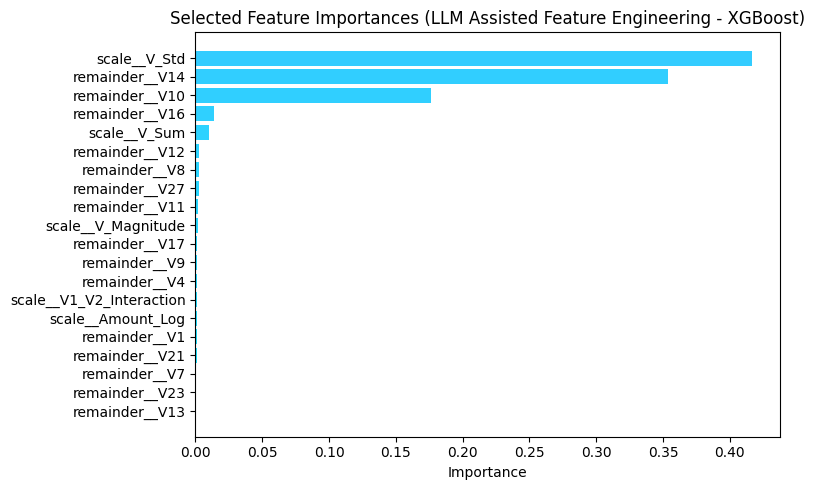

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Get feature importances from the feature selection model
importances = selector.estimator_.feature_importances_

# Keep only selected ones
selected_importances = importances[support_mask]

# Sort them
indices = np.argsort(selected_importances)

# Use a pastel colormap
#colors = cm.Pastel1(np.linspace(0, 1, len(indices)))
colors = cm.cool(np.linspace(0.1, 0.2, len(indices)))


plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), selected_importances[indices],color=colors)
plt.yticks(range(len(indices)), selected_names[indices])
plt.title("Selected Feature Importances (LLM Assisted Feature Engineering - XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

XGB - SMOTE

In [34]:
xgb_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectFromModel(
        xgb.XGBClassifier(n_estimators=100, random_state=42),
        threshold="median" # Keeps the top 50% of features
    )),
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        scale_pos_weight=None,
        max_depth=None,
        gamma=1,
        learning_rate=0.1,
        n_estimators=100,
    ))
])

# Train on the SMOTE-resampled training data
xgb_smote.fit(X_train, y_train)
y_pred_proba_smote = xgb_smote.predict_proba(X_test)[:, 1]
y_pred_class_smote = xgb_smote.predict(X_test)

metrics_smote = evaluate_model(y_test, y_pred_proba_smote, y_pred_class_smote, "XGBoost","SMOTE")
final_results.append(metrics_smote)
print(pd.Series(metrics_smote))

confusion_matrix:
 [[85099   196]
 [   25   123]]
Model                    XGBoost
Method                     SMOTE
PR-AUC                  0.783668
ROC-AUC                 0.973318
Recall (Fraud)          0.831081
Precision (Fraud)        0.38558
F1-Score                0.526767
True Positives (TP)          123
False Negatives (FN)          25
dtype: object


In [35]:
# 1. Get original feature names from the preprocessor
feature_names = xgb_smote.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the selection mask
selector = xgb_smote.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Apply mask to names
selected_names = feature_names[support_mask]

# 4. Map back to the FINAL classifier's feature importances
importances = xgb_smote.named_steps['classifier'].feature_importances_
xgb_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Features selected: {len(selected_names)} out of {len(feature_names)}")
print(xgb_importance_series.head(10))

Features selected: 20 out of 40
remainder__V14              0.627090
remainder__V4               0.054673
scale__Is_Round_Amount      0.034439
scale__V_Magnitude          0.030221
scale__Time_Delta           0.025249
remainder__V10              0.024311
remainder__V12              0.023356
scale__V1_V2_Interaction    0.019958
remainder__V8               0.019013
remainder__V11              0.018214
dtype: float32


In [36]:
results_df = pd.DataFrame(final_results)
print(results_df[[
    'Model',
    'Method',
    'PR-AUC',
    'ROC-AUC',
    'Recall (Fraud)',
    'Precision (Fraud)',
    'F1-Score',
    'True Positives (TP)',
    'False Negatives (FN)'
]])

     Model Method    PR-AUC   ROC-AUC  Recall (Fraud)  Precision (Fraud)  \
0       LR     CW  0.677168  0.962458        0.864865           0.057971   
1       LR  SMOTE  0.704671  0.968808        0.878378           0.060861   
2       RF     CW  0.815362  0.930541        0.722973           0.963964   
3       RF  SMOTE  0.804235  0.952069        0.824324           0.589372   
4      XGB     CW  0.808375  0.966725        0.810811           0.670391   
5  XGBoost  SMOTE  0.783668  0.973318        0.831081           0.385580   

   F1-Score  True Positives (TP)  False Negatives (FN)  
0  0.108659                  128                    20  
1  0.113835                  130                    18  
2  0.826255                  107                    41  
3  0.687324                  122                    26  
4  0.733945                  120                    28  
5  0.526767                  123                    25  


Generating SHAP for logistic Regression...


  0%|          | 0/100 [00:00<?, ?it/s]

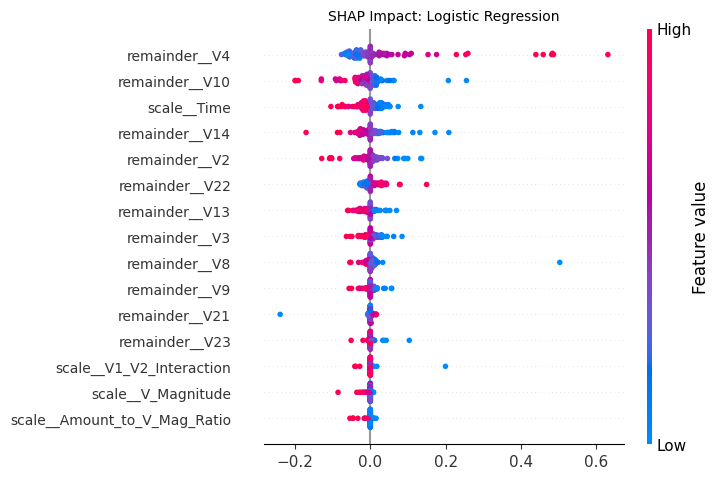

In [37]:
# --- LOGISTIC REGRESSION SHAP ---
import shap
import matplotlib.pyplot as plt
import numpy as np


model_name = 'logistic Regression' # Or 'lr_smote'
pipeline = lr_cw 

print(f"Generating SHAP for {model_name}...")

# 1. Transform data through preprocessor and RFE selector
X_pre = pipeline.named_steps['preprocessor'].transform(X_test)
X_final = pipeline.named_steps['selector'].transform(X_pre)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()[pipeline.named_steps['selector'].get_support()]

# 2. SHAP KernelExplainer
explainer = shap.KernelExplainer(lambda x: pipeline.named_steps['classifier'].predict_proba(x)[:, 1], X_final[:20])
shap_values = explainer.shap_values(X_final[:100])

# 3. Plotting
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_final[:100], feature_names=feature_names, max_display=15, plot_size=(8,5), show=False)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.title(f"SHAP Impact: Logistic Regression", fontsize=10)
plt.show()

Generating SHAP for rf_cw...


  0%|          | 0/100 [00:00<?, ?it/s]

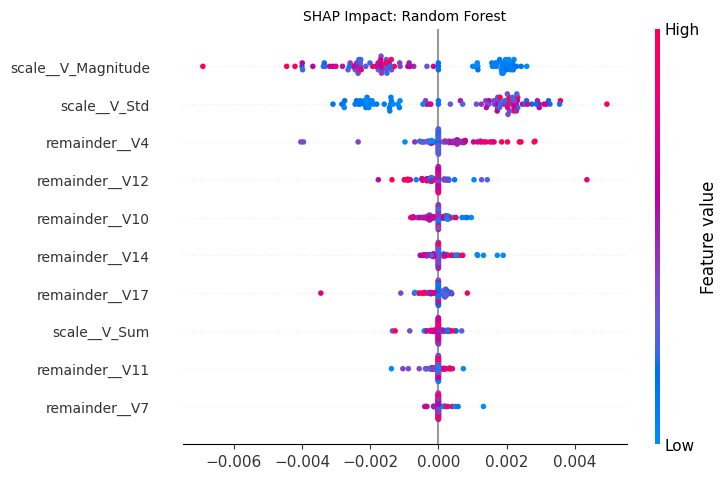

In [38]:
# --- RANDOM FOREST SHAP ---
model_name = 'rf_cw' # Or 'rf_smote'
pipeline = rf_cw

print(f"Generating SHAP for {model_name}...")

# 1. Transform data
X_pre = pipeline.named_steps['preprocessor'].transform(X_test)
X_final = pipeline.named_steps['feature_selection'].transform(X_pre)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()[pipeline.named_steps['feature_selection'].get_support()]

# 2. SHAP KernelExplainer
explainer = shap.KernelExplainer(lambda x: pipeline.named_steps['classifier'].predict_proba(x)[:, 1], X_final[:20])
shap_values = explainer.shap_values(X_final[:100])

# 3. Plotting
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_final[:100], feature_names=feature_names, max_display=15, plot_size=(8, 5), show=False)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.title(f"SHAP Impact: Random Forest", fontsize=10)
plt.show()

Generating SHAP for xgb_cw...


  0%|          | 0/100 [00:00<?, ?it/s]

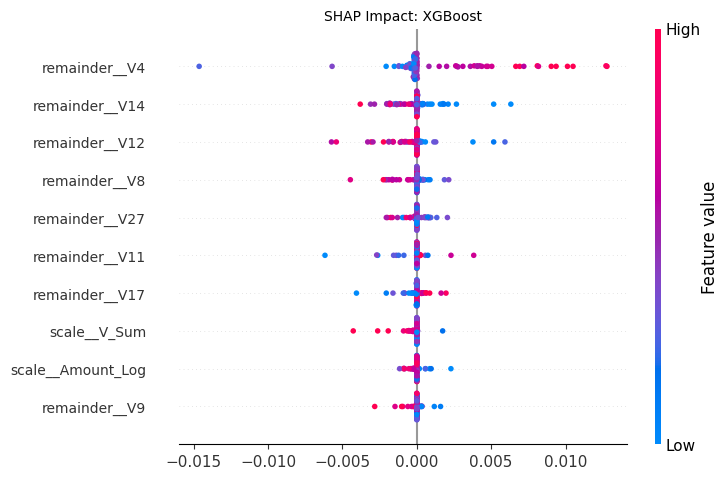

In [39]:
# --- XGBOOST SHAP ---
model_name = 'xgb_cw' # Or 'xgb_smote'
pipeline = xgb_cw

print(f"Generating SHAP for {model_name}...")

# 1. Transform data
X_pre = pipeline.named_steps['preprocessor'].transform(X_test)
X_final = pipeline.named_steps['feature_selection'].transform(X_pre)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()[pipeline.named_steps['feature_selection'].get_support()]

# 2. SHAP KernelExplainer
explainer = shap.KernelExplainer(lambda x: pipeline.named_steps['classifier'].predict_proba(x)[:, 1], X_final[:20])
shap_values = explainer.shap_values(X_final[:100])

# 3. Plotting
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_final[:100], feature_names=feature_names, max_display=10, plot_size=(8, 5), show=False)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.title(f"SHAP Impact: XGBoost", fontsize=10)
plt.show()